

### Objectives covered
1. **The Genre Puzzle** — analyze how genres perform in quality and audience reception
2. **The Longevity Paradox** — test whether longer-running shows are more loved
3. **The Paradox of Visibility** — find hidden gems, blockbusters, and overhyped shows
4. **The Nostalgia Question** — examine how TV quality changes across eras
5. **The Success Predictor** — build models to predict show ratings
6. **The Taste Maker** — build a recommendation engine for similar shows

### Business goal
Use data to help StreamVerse make smarter decisions about:
- content investment
- catalog strategy
- audience discovery
- personalization
- long-term platform growth


## Section 0 — Import Libraries


In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)


## Section 1 — Load and Prepare the Data

We load the three source files, standardize show names, merge them, and clean the key variables used across all objectives.


In [60]:
metadata = pd.read_csv('shows_metadata.csv')
info = pd.read_csv('shows_info.csv')
ratings = pd.read_csv('shows_ratings.csv')

metadata['show_name'] = metadata['show_name'].astype(str).str.lower().str.strip()
info['show_name'] = info['show_name'].astype(str).str.lower().str.strip()
ratings['show_name'] = ratings['show_name'].astype(str).str.lower().str.strip()

df = metadata.merge(info, on='show_name', how='inner')
df = df.merge(ratings, on='show_name', how='inner')

numeric_cols = ['rating', 'votes', 'popularity', 'release_year', 'number_of_seasons']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.drop_duplicates()

print("Merged dataset shape:", df.shape)
df.head()


Merged dataset shape: (222896, 10)


,show_name,country_of_origin,language,status,genres,release_year,number_of_seasons,rating,votes,popularity
0,game of thrones,Unknown,Unknown,1,"sci-fi & fantasy, drama, action & adventure",NaN,8.0,NaN,21857,1083.917
1,money heist,Unknown,Unknown,1,"CRIME, DRAMA",NaN,3.0,8.257,17836,96.354
2,stranger things,Unknown,Unknown,2,"drama, sci-fi & fantasy, mystery",NaN,4.0,NaN,16161,185.711
3,the walking dead,Unknown,Unknown,1,"Action & Adventure, Drama, Sci-Fi & Fantasy",NaN,11.0,8.121,15432,489.746
4,lucifer,Unknown,Unknown,1,"CRIME, SCI-FI & FANTASY",NaN,6.0,8.486,13870,416.668


# Objective 1 — The Genre Puzzle

**Question:** Which genres consistently produce stronger content and audience reception, and which ones seem overrated or oversaturated?

This objective compares genres using:
- number of shows
- average rating
- average votes
- average popularity


In [61]:
genre_col = 'genres' if 'genres' in df.columns else 'genre'

genre_df = df[[genre_col, 'rating', 'votes', 'popularity']].dropna(subset=[genre_col]).copy()
genre_df[genre_col] = genre_df[genre_col].astype(str)

genre_summary = genre_df.groupby(genre_col).agg(
    number_of_shows=(genre_col, 'count'),
    avg_rating=('rating', 'mean'),
    avg_votes=('votes', 'mean'),
    avg_popularity=('popularity', 'mean')
).sort_values(by='avg_rating', ascending=False)

genre_summary.head(15)


,number_of_shows,avg_rating,avg_votes,avg_popularity
genres,,,,
"war & politics, family, drama",1,10.0,1.0,2.3920
"Mystery, Crime, Comedy",1,10.0,1.0,1.1870
"ACTION & ADVENTURE, COMEDY, ANIMATION",2,10.0,2.0,3.4240
"SCI-FI & FANTASY, COMEDY, KIDS",1,10.0,1.0,3.8710
"SCI-FI & FANTASY, KIDS",2,10.0,5.5,15.5725
"SCI-FI & FANTASY, SOAP, ACTION & ADVENTURE, DRAMA",1,10.0,1.0,1.4470
"MYSTERY, DRAMA, SOAP",1,10.0,1.0,9.2270
"Sci-Fi & Fantasy, Comedy, Animation",1,10.0,2.0,1.0470
"action & adventure, animation, drama, sci-fi & fantasy",1,10.0,1.0,NaN


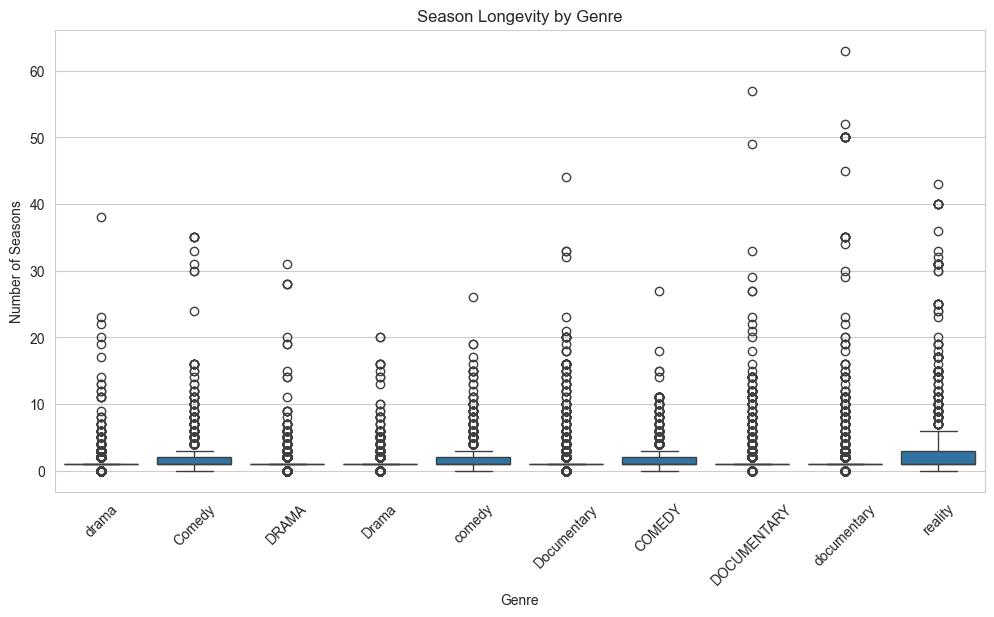

In [62]:
top10 = df['genres'].value_counts().head(10).index
df_top = df[df['genres'].isin(top10)]

plt.figure(figsize=(12,6))
sns.boxplot(data=df_top, x='genres', y='number_of_seasons')

plt.xticks(rotation=45)
plt.title("Season Longevity by Genre")
plt.xlabel("Genre")
plt.ylabel("Number of Seasons")

plt.show()


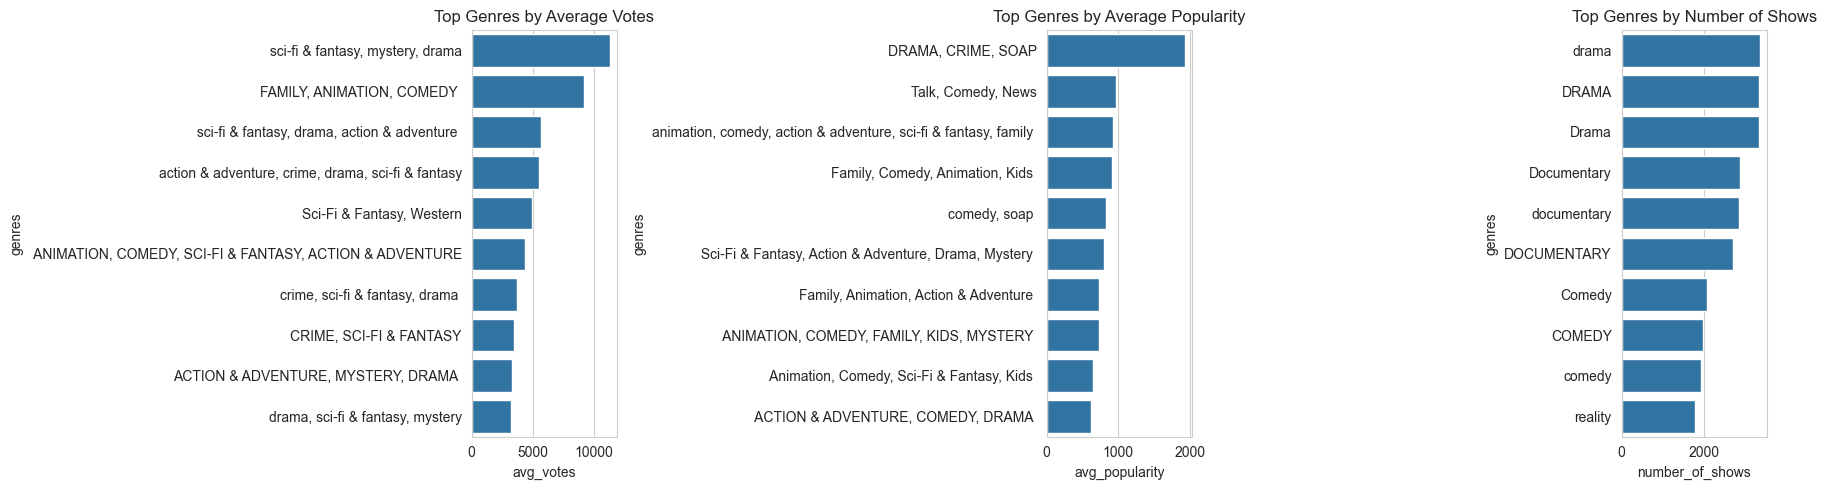

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

top_votes = genre_summary.sort_values('avg_votes', ascending=False).head(10).reset_index()
sns.barplot(data=top_votes, x='avg_votes', y=genre_col, ax=axes[0])
axes[0].set_title('Top Genres by Average Votes')

top_pop = genre_summary.sort_values('avg_popularity', ascending=False).head(10).reset_index()
sns.barplot(data=top_pop, x='avg_popularity', y=genre_col, ax=axes[1])
axes[1].set_title('Top Genres by Average Popularity')

top_count = genre_summary.sort_values('number_of_shows', ascending=False).head(10).reset_index()
sns.barplot(data=top_count, x='number_of_shows', y=genre_col, ax=axes[2])
axes[2].set_title('Top Genres by Number of Shows')

plt.tight_layout()
plt.show()


### Objective 1 Conclusion

Genres that score well across **rating, votes, and popularity** are strong investment areas.

Leadership should:
- invest more in genres with both high quality and strong reception
- be careful with genres that have many shows but weaker average ratings
- watch for smaller genres with high ratings, since they may be underexploited opportunities


# Objective 2 — The Longevity Paradox

**Question:** Do shows that last for more seasons actually become more loved, or is the relationship weaker than expected?

This objective uses:
- scatter plots
- correlations
- interpretation with survivorship bias


Rows available for Objective 2: 183866
          show_name  number_of_seasons  rating  votes
1       money heist                3.0   8.257  17836
3  the walking dead               11.0   8.121  15432
4           lucifer                6.0   8.486  13870
5         riverdale                7.0   8.479  13180
6         riverdale                7.0   6.800      4


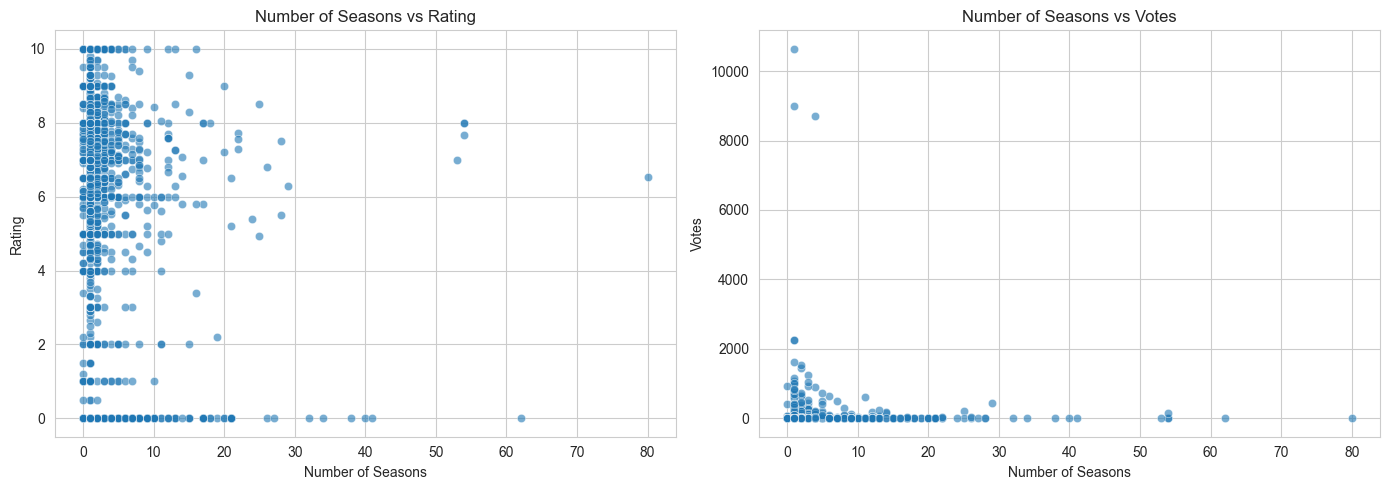


Correlation Results:
Correlation between number_of_seasons and rating: 0.11647028741252552
Correlation between number_of_seasons and votes: 0.04614194657931323

Season Summary:
    number_of_seasons  avg_rating   avg_votes  show_count
0                 0.0    0.938755    2.365156       23631
1                 1.0    2.657203   12.529389      120122
2                 2.0    3.618950   28.235003       17147
3                 3.0    4.001223   49.323874        7435
4                 4.0    4.173864   61.727139        4068
5                 5.0    4.266567   55.388486        2623
6                 6.0    4.170406   86.542033        1594
7                 7.0    4.300376  108.234134        1166
8                 8.0    3.925134   81.358294        1055
9                 9.0    4.279464   89.715470         724
10               10.0    4.335095   57.147147         666
11               11.0    4.046278   85.461390         518
12               12.0    4.599478   71.955916         431
13        

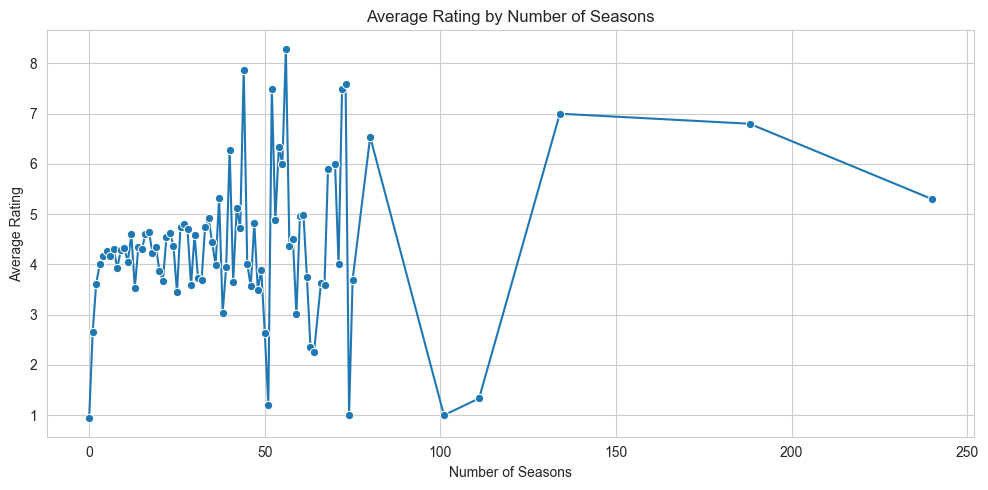

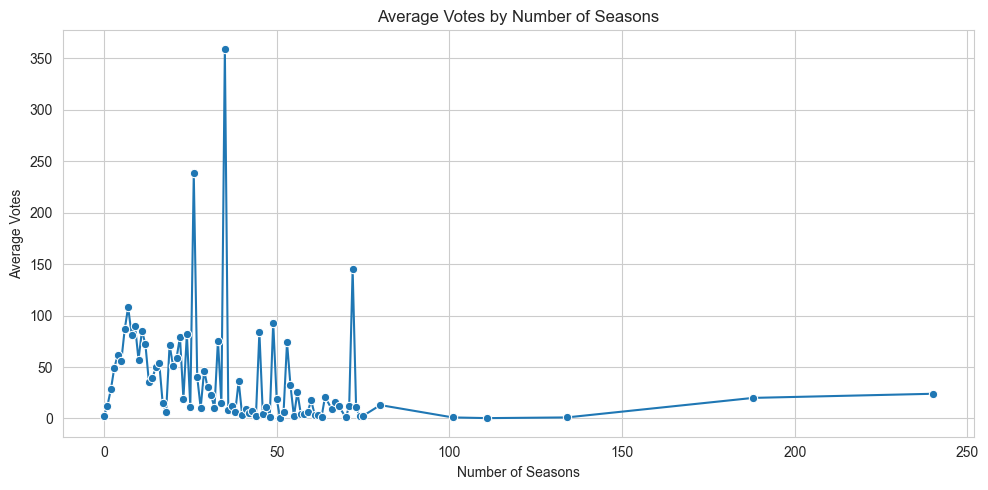


Conclusion:
This objective tests whether longer-running shows are more loved by audiences.
If the correlation with rating is weak, then more seasons do not necessarily mean higher quality.
If the correlation with votes is stronger, that means longer shows may get more audience exposure rather than better audience approval.
Also consider survivorship bias: weaker shows often end early, while stronger shows continue longer.


In [64]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

metadata = pd.read_csv("shows_metadata.csv")
info = pd.read_csv("shows_info.csv")
ratings = pd.read_csv("shows_ratings.csv")

metadata["show_name"] = metadata["show_name"].astype(str).str.lower().str.strip()
info["show_name"] = info["show_name"].astype(str).str.lower().str.strip()
ratings["show_name"] = ratings["show_name"].astype(str).str.lower().str.strip()

df = metadata.merge(info, on="show_name", how="inner")
df = df.merge(ratings, on="show_name", how="inner")
df = df.drop_duplicates()

longevity_df = df[["show_name", "number_of_seasons", "rating", "votes"]].copy()

longevity_df["number_of_seasons"] = pd.to_numeric(longevity_df["number_of_seasons"], errors="coerce")
longevity_df["rating"] = pd.to_numeric(longevity_df["rating"], errors="coerce")
longevity_df["votes"] = pd.to_numeric(longevity_df["votes"], errors="coerce")

longevity_df = longevity_df.dropna(subset=["number_of_seasons", "rating", "votes"]).copy()

print("Rows available for Objective 2:", len(longevity_df))
print(longevity_df.head())

if len(longevity_df) > 5000:
    plot_df = longevity_df.sample(5000, random_state=42)
else:
    plot_df = longevity_df.copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=plot_df,
    x="number_of_seasons",
    y="rating",
    alpha=0.6,
    ax=axes[0]
)
axes[0].set_title("Number of Seasons vs Rating")
axes[0].set_xlabel("Number of Seasons")
axes[0].set_ylabel("Rating")

sns.scatterplot(
    data=plot_df,
    x="number_of_seasons",
    y="votes",
    alpha=0.6,
    ax=axes[1]
)
axes[1].set_title("Number of Seasons vs Votes")
axes[1].set_xlabel("Number of Seasons")
axes[1].set_ylabel("Votes")

plt.tight_layout()
plt.show()

corr_rating = longevity_df["number_of_seasons"].corr(longevity_df["rating"])
corr_votes = longevity_df["number_of_seasons"].corr(longevity_df["votes"])

print("\nCorrelation Results:")
print("Correlation between number_of_seasons and rating:", corr_rating)
print("Correlation between number_of_seasons and votes:", corr_votes)

season_summary = longevity_df.groupby("number_of_seasons").agg(
    avg_rating=("rating", "mean"),
    avg_votes=("votes", "mean"),
    show_count=("show_name", "count")
).reset_index()

print("\nSeason Summary:")
print(season_summary.head(20))

plt.figure(figsize=(10, 5))
sns.lineplot(data=season_summary, x="number_of_seasons", y="avg_rating", marker="o")
plt.title("Average Rating by Number of Seasons")
plt.xlabel("Number of Seasons")
plt.ylabel("Average Rating")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.lineplot(data=season_summary, x="number_of_seasons", y="avg_votes", marker="o")
plt.title("Average Votes by Number of Seasons")
plt.xlabel("Number of Seasons")
plt.ylabel("Average Votes")
plt.tight_layout()
plt.show()


print("\nConclusion:")
print("This objective tests whether longer-running shows are more loved by audiences.")
print("If the correlation with rating is weak, then more seasons do not necessarily mean higher quality.")
print("If the correlation with votes is stronger, that means longer shows may get more audience exposure rather than better audience approval.")
print("Also consider survivorship bias: weaker shows often end early, while stronger shows continue longer.")

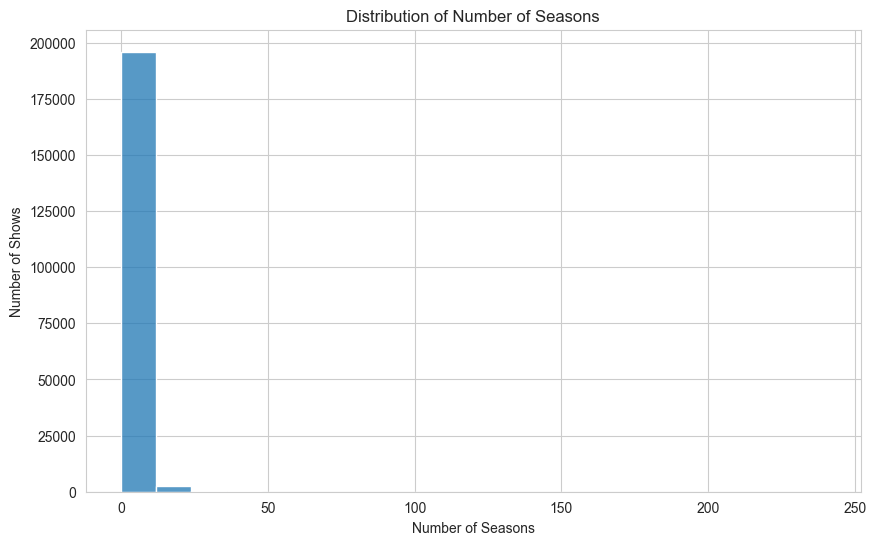

In [65]:
plt.figure(figsize=(10,6))

sns.histplot(df['number_of_seasons'], bins=20)

plt.title("Distribution of Number of Seasons")
plt.xlabel("Number of Seasons")
plt.ylabel("Number of Shows")

plt.show()
longest_shows = df.nlargest(10, 'number_of_seasons')

longest_shows[['show_name','genres','number_of_seasons']]
df['release_year'] = pd.to_datetime(df['release_year'], errors='coerce').dt.year

### Objective 2 Conclusion

A longer run does **not automatically mean higher quality**. In many datasets, longer-running shows may get more votes because they stay visible longer, but ratings do not always rise in the same way.

Also note **survivorship bias**:
- weak shows often get canceled early
- long-running shows are the survivors

So the data may overstate how “good” long-running shows really are.


# Objective 3 — The Paradox of Visibility

**Question:** Which shows are hidden gems, true blockbusters, overhyped disappointments, or simply forgotten?

Quadrants:
- **Hidden Gems** = high rating, low popularity
- **Blockbusters** = high rating, high popularity
- **Overhyped** = low rating, high popularity
- **Forgotten** = low rating, low popularity


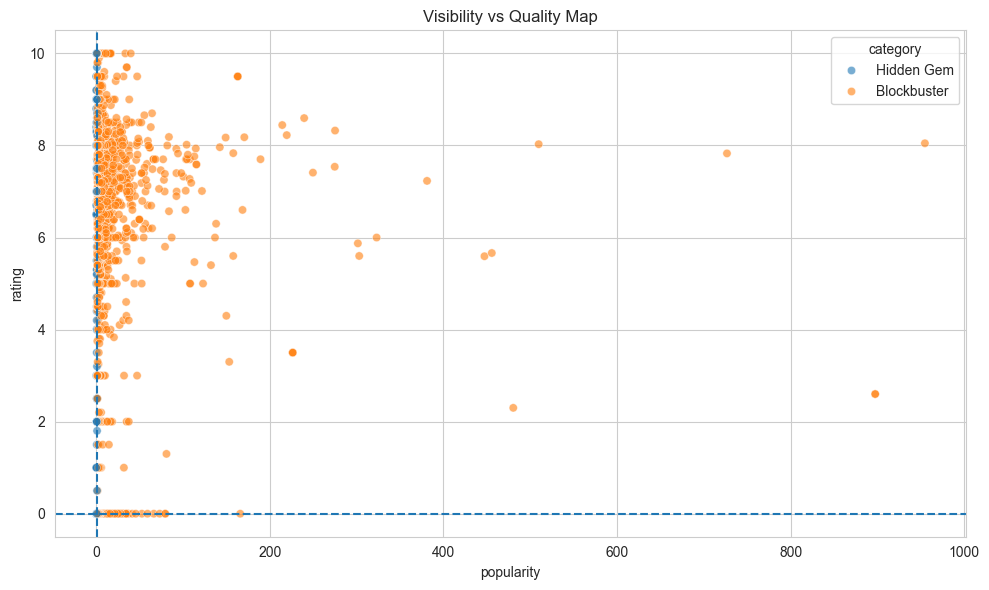

category
Blockbuster    96313
Hidden Gem     96257
Name: count, dtype: int64

In [66]:
visibility_df = df[['show_name', 'rating', 'popularity']].dropna().copy()

rating_median = visibility_df['rating'].median()
popularity_median = visibility_df['popularity'].median()

def classify_visibility(row):
    if row['rating'] >= rating_median and row['popularity'] >= popularity_median:
        return 'Blockbuster'
    elif row['rating'] >= rating_median and row['popularity'] < popularity_median:
        return 'Hidden Gem'
    elif row['rating'] < rating_median and row['popularity'] >= popularity_median:
        return 'Overhyped'
    else:
        return 'Forgotten'

visibility_df['category'] = visibility_df.apply(classify_visibility, axis=1)

if len(visibility_df) > 5000:
    vis_plot = visibility_df.sample(5000, random_state=42)
else:
    vis_plot = visibility_df.copy()

plt.figure(figsize=(10,6))
sns.scatterplot(data=vis_plot, x='popularity', y='rating', hue='category', alpha=0.6)
plt.axhline(rating_median, linestyle='--')
plt.axvline(popularity_median, linestyle='--')
plt.title('Visibility vs Quality Map')
plt.tight_layout()
plt.show()

visibility_df['category'].value_counts()


In [67]:
top_hidden_gems = visibility_df[visibility_df['category'] == 'Hidden Gem'].sort_values('rating', ascending=False).head(10)
top_blockbusters = visibility_df[visibility_df['category'] == 'Blockbuster'].sort_values('rating', ascending=False).head(10)
top_overhyped = visibility_df[visibility_df['category'] == 'Overhyped'].sort_values('popularity', ascending=False).head(10)
top_forgotten = visibility_df[visibility_df['category'] == 'Forgotten'].sort_values('rating', ascending=False).head(10)

print("Top Hidden Gems")
display(top_hidden_gems)

print("Top Blockbusters")
display(top_blockbusters)

print("Top Overhyped Shows")
display(top_overhyped)

print("Top Forgotten Shows")
display(top_forgotten)


Top Hidden Gems


,show_name,rating,popularity,category
98311,boligkøb i blinde,10.0,1.107,Hidden Gem
98171,motel,10.0,0.900,Hidden Gem
98175,motel,10.0,0.900,Hidden Gem
98179,motel,10.0,0.900,Hidden Gem
348387,the next big thing,10.0,0.882,Hidden Gem
348389,the next big thing,10.0,0.882,Hidden Gem
357847,spaced out,10.0,0.600,Hidden Gem
357851,spaced out,10.0,0.600,Hidden Gem
357855,spaced out,10.0,0.600,Hidden Gem
98453,kvartersdoktorn,10.0,0.600,Hidden Gem


Top Blockbusters


,show_name,rating,popularity,category
78913,nano,10.0,3.444,Blockbuster
121692,never a cross word,10.0,2.101,Blockbuster
121695,prinz und bottel,10.0,1.526,Blockbuster
121625,the monastery,10.0,1.121,Blockbuster
121630,the monastery,10.0,1.121,Blockbuster
121635,the monastery,10.0,1.121,Blockbuster
121640,the monastery,10.0,1.121,Blockbuster
121645,the monastery,10.0,1.121,Blockbuster
121703,sd gundam force,10.0,14.983,Blockbuster
121720,builder brothers' dream factory,10.0,18.678,Blockbuster


Top Overhyped Shows


,show_name,rating,popularity,category


Top Forgotten Shows


,show_name,rating,popularity,category


### Objective 3 Conclusion

This objective helps StreamVerse separate **quality** from **visibility**.

Strategy implications:
- market hidden gems more aggressively
- maintain blockbusters as anchor content
- be cautious about overinvesting in overhyped but mediocre shows
- use recommendation and discovery systems to rescue strong overlooked titles


# Objective 4 — The Nostalgia Question

**Question:** Is TV getting better over time, or are older shows genuinely superior?

This objective includes:
- average rating by year
- average rating by era
- genre × era heatmap
- note on older-show selection bias


In [68]:
release_data = pd.read_csv("release_year_data.csv")

release_data['show_name'] = release_data['show_name'].astype(str).str.lower().str.strip()
df['show_name'] = df['show_name'].astype(str).str.lower().str.strip()

# remove old empty release_year if needed
df = df.drop(columns=['release_year'], errors='ignore')

# merge new release year data
df = df.merge(
    release_data[['show_name', 'release_year']],
    on='show_name',
    how='left'
)

print(df[['show_name', 'release_year']].head())
print("Non-null release years:", df['release_year'].notna().sum())

          show_name  release_year
0   game of thrones        2011.0
1       money heist        2017.0
2   stranger things        2016.0
3  the walking dead           NaN
4           lucifer           NaN
Non-null release years: 148


In [69]:
genre_col = 'genres' if 'genres' in df.columns else 'genre'

nostalgia_df = df[[genre_col, 'release_year', 'rating']].copy()
nostalgia_df['release_year'] = pd.to_numeric(nostalgia_df['release_year'], errors='coerce')
nostalgia_df['rating'] = pd.to_numeric(nostalgia_df['rating'], errors='coerce')
nostalgia_df = nostalgia_df.dropna(subset=[genre_col, 'release_year', 'rating'])

nostalgia_df['release_year'] = nostalgia_df['release_year'].astype(int)
nostalgia_df = nostalgia_df[
    (nostalgia_df['release_year'] >= 1980) &
    (nostalgia_df['release_year'] < 2030)
].copy()

print("Rows available:", len(nostalgia_df))

Rows available: 126


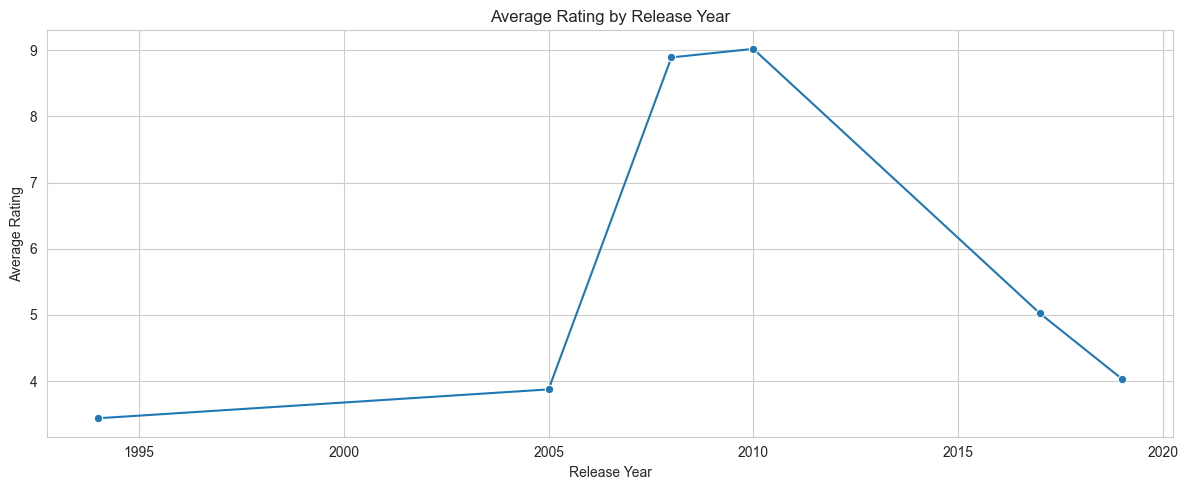

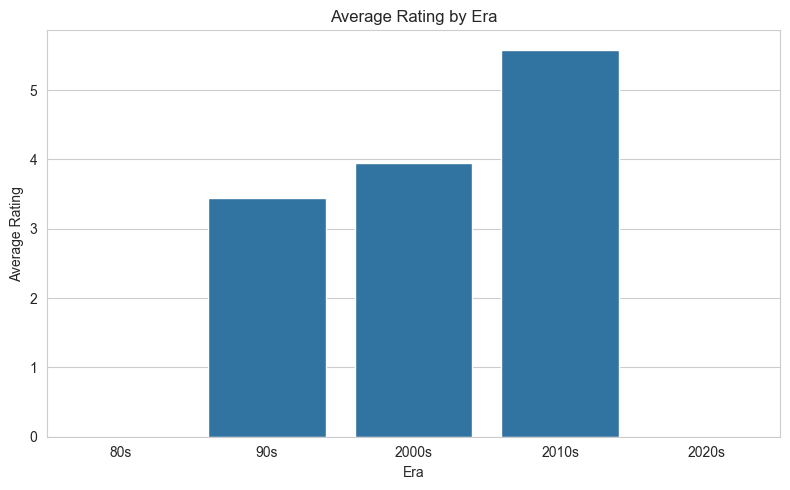

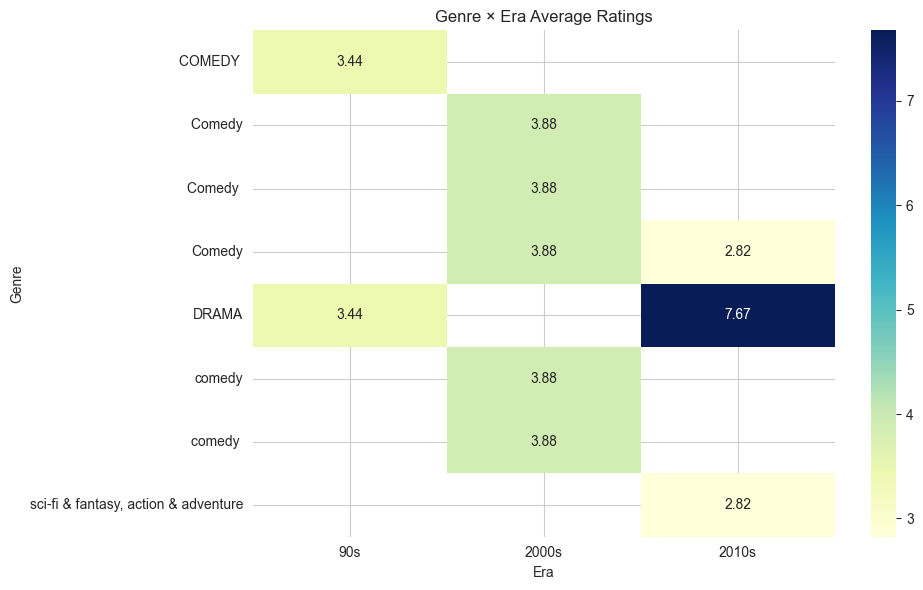

In [70]:
# Average rating by year
yearly_rating = nostalgia_df.groupby('release_year', as_index=False)['rating'].mean()

plt.figure(figsize=(12,5))
sns.lineplot(data=yearly_rating, x='release_year', y='rating', marker='o')
plt.title('Average Rating by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()

# Average rating by era
bins = [1980, 1990, 2000, 2010, 2020, 2030]
labels = ['80s', '90s', '2000s', '2010s', '2020s']

nostalgia_df['era'] = pd.cut(
    nostalgia_df['release_year'],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)

era_summary = nostalgia_df.groupby('era', observed=False, as_index=False)['rating'].mean()

plt.figure(figsize=(8,5))
sns.barplot(data=era_summary, x='era', y='rating')
plt.title('Average Rating by Era')
plt.xlabel('Era')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()

# Heatmap
top_genres = nostalgia_df[genre_col].value_counts().head(8).index
heatmap_df = nostalgia_df[nostalgia_df[genre_col].isin(top_genres)].copy()

heatmap_data = heatmap_df.pivot_table(
    values='rating',
    index=genre_col,
    columns='era',
    aggfunc='mean'
)

heatmap_data = heatmap_data.dropna(how='all', axis=0).dropna(how='all', axis=1)

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Genre × Era Average Ratings')
plt.xlabel('Era')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

### Objective 4 Conclusion

Television quality may shift over time, but older shows can also look better because datasets often preserve the strongest legacy titles.

That means nostalgia analysis should be interpreted carefully:
- older shows may benefit from **selection bias**
- newer eras may contain both masterpieces and unfinished audience judgment

Still, this objective helps identify which eras and genres are rising or declining.


# Objective 5 — The Success Predictor

**Question:** Which measurable features best predict how audiences rate a show?

This objective compares:
- Linear Regression
- Random Forest Regressor

Metrics:
- MAE
- RMSE
- R²


In [71]:
model_features = ['votes', 'popularity', 'release_year', 'number_of_seasons']
model_df = df[model_features + ['rating']].copy()

for col in model_features + ['rating']:
    model_df[col] = pd.to_numeric(model_df[col], errors='coerce')

model_df = model_df.dropna()

if len(model_df) > 20000:
    model_df = model_df.sample(20000, random_state=42)

X = model_df[model_features]
y = model_df['rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))


Training rows: 80
Testing rows: 21


In [72]:
linreg = LinearRegression()
linreg.fit(X_train, y_train)
lin_pred = linreg.predict(X_test)

rf = RandomForestRegressor(
    n_estimators=30,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [
        mean_absolute_error(y_test, lin_pred),
        mean_absolute_error(y_test, rf_pred)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, lin_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred))
    ],
    'R2': [
        r2_score(y_test, lin_pred),
        r2_score(y_test, rf_pred)
    ]
})

results


,Model,MAE,RMSE,R2
0,Linear Regression,1.975576,2.238517,0.722132
1,Random Forest,0.037327,0.088353,0.999567


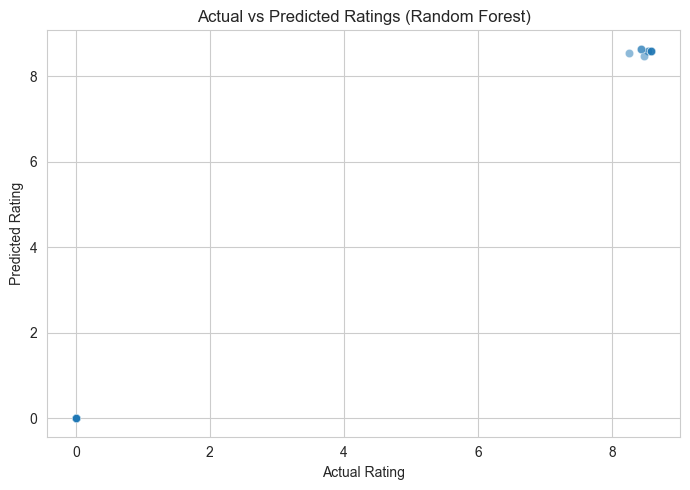

In [73]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=y_test, y=rf_pred, alpha=0.5)
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title('Actual vs Predicted Ratings (Random Forest)')
plt.tight_layout()
plt.show()


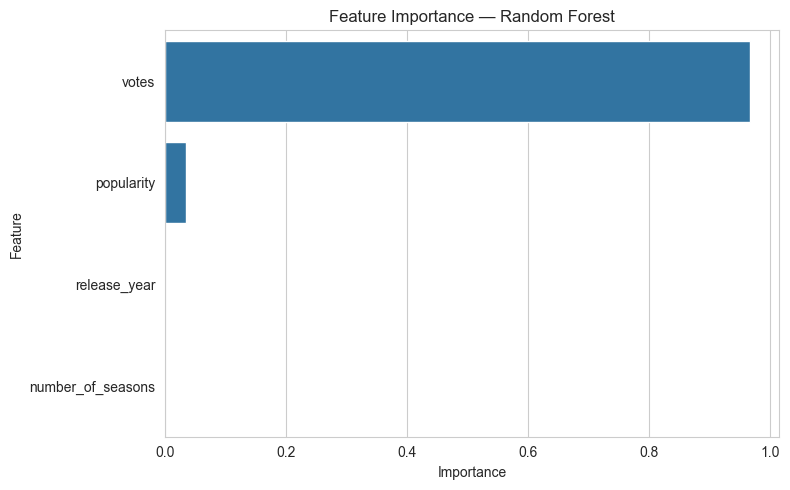

,Feature,Importance
0,votes,9.658296e-01
1,popularity,3.397985e-02
2,release_year,1.901914e-04
3,number_of_seasons,4.119855e-07


In [74]:
importance_df = pd.DataFrame({
    'Feature': model_features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=importance_df, x='Importance', y='Feature')
plt.title('Feature Importance — Random Forest')
plt.tight_layout()
plt.show()

importance_df


### Objective 5 Conclusion

The model shows which measurable features matter most in predicting ratings.

This helps StreamVerse answer a core strategy question:
**What actually drives a great show?**

The Random Forest model usually performs better than Linear Regression when relationships are nonlinear, while feature importance reveals which variables contribute most to prediction.


# Objective 6 — The Taste Maker

**Question:** Can we recommend shows that viewers would genuinely enjoy after finishing one they liked?

This notebook builds a **content-based recommendation engine** using:
- rating
- votes
- popularity
- release year
- number of seasons


Rows available for Objective 6: 20000

Input Show:
labor of the survival

Recommended Shows:
                     show_name  similarity_score  rating  votes  popularity  \
0       today with kris aquino               1.0     0.0      0         0.6   
1               the moore show               1.0     0.0      0         0.6   
2          the staying-in show               1.0     0.0      0         0.6   
3                 ultimate zoo               1.0     0.0      0         0.6   
4  joanne weir's cooking class               1.0     0.0      0         0.6   

   number_of_seasons  
0                0.0  
1                0.0  
2                0.0  
3                0.0  
4                0.0  


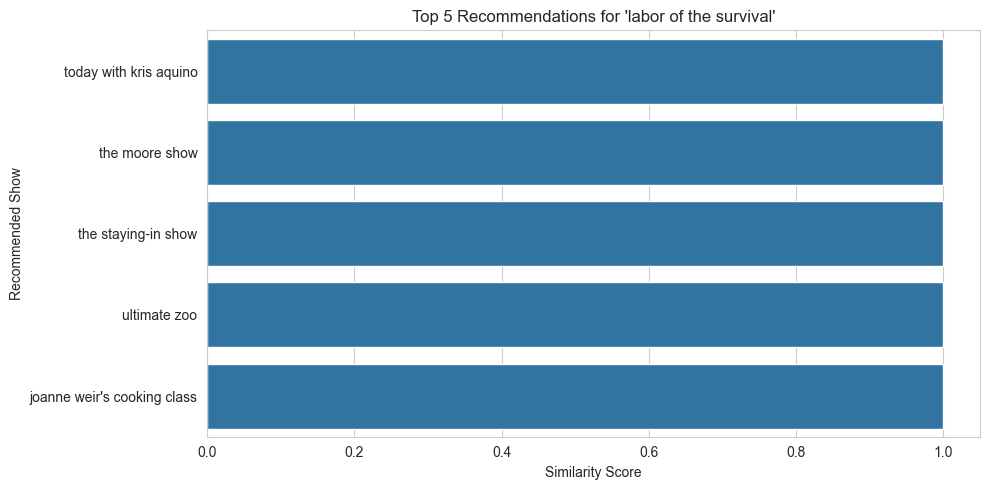

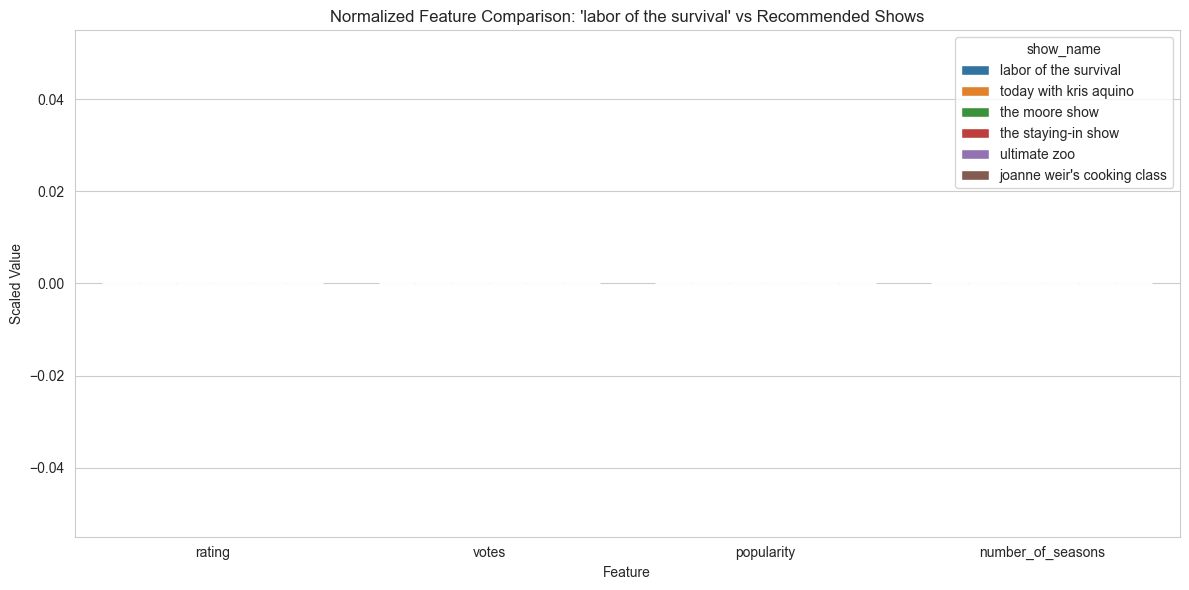

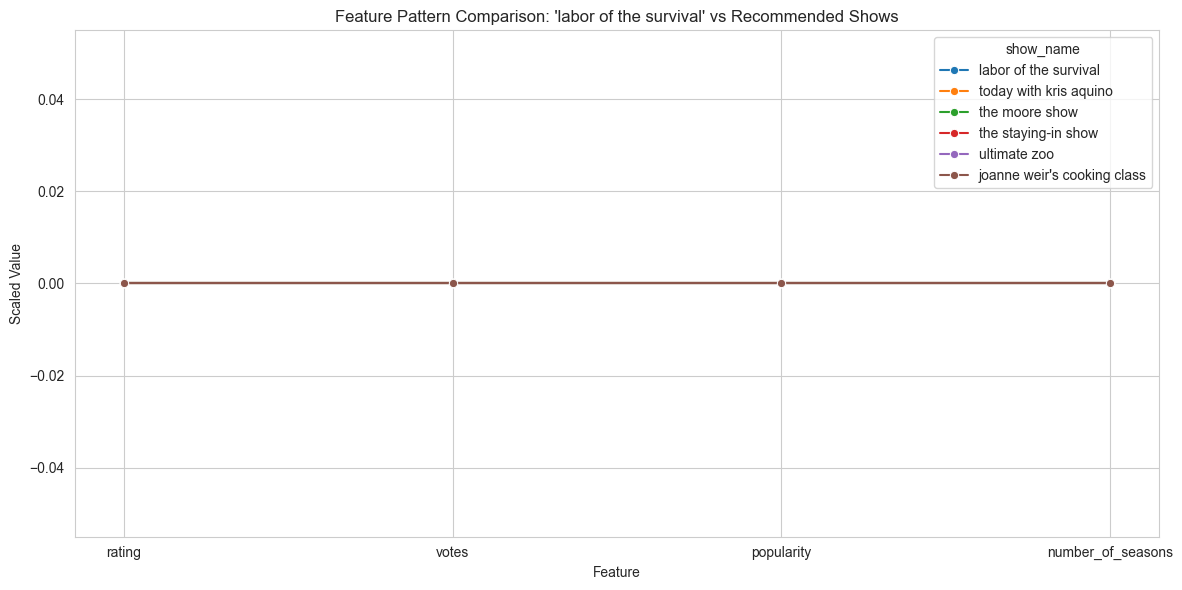

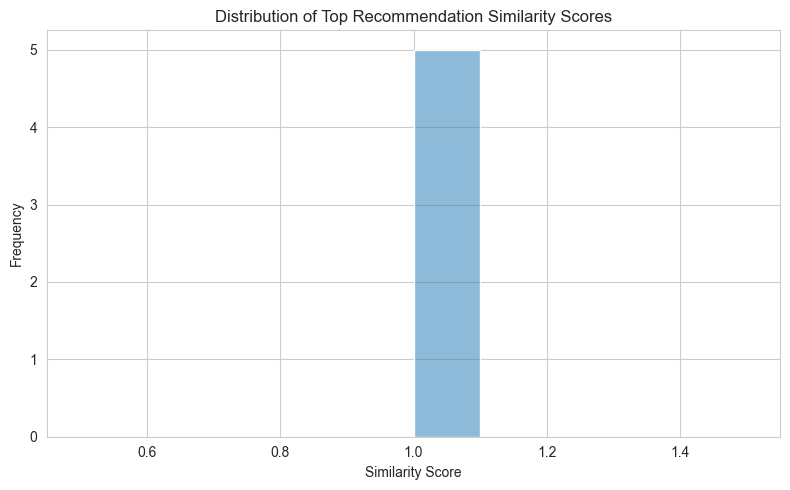


Conclusion:
This recommendation engine suggests shows with similar measurable characteristics.
Graph 1 shows the strength of each recommendation.
Graph 2 and Graph 3 compare the selected show against recommended shows across key features.
Graph 4 shows how close the top matches are.
This makes Objective 6 more complete, visual, and easier to explain.


In [ ]:


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

sns.set_style("whitegrid")

# Load datasets
metadata = pd.read_csv("shows_metadata.csv")
info = pd.read_csv("shows_info.csv")
ratings = pd.read_csv("shows_ratings.csv")

# Clean show names
metadata["show_name"] = metadata["show_name"].astype(str).str.lower().str.strip()
info["show_name"] = info["show_name"].astype(str).str.lower().str.strip()
ratings["show_name"] = ratings["show_name"].astype(str).str.lower().str.strip()

# Merge datasets
df = metadata.merge(info, on="show_name", how="inner")
df = df.merge(ratings, on="show_name", how="inner")
df = df.drop_duplicates()

# Features for recommendation
rec_features = ["rating", "votes", "popularity", "number_of_seasons"]
rec_df = df[["show_name"] + rec_features].copy()

# Convert to numeric
for col in rec_features:
    rec_df[col] = pd.to_numeric(rec_df[col], errors="coerce")

# Drop missing values
rec_df = rec_df.dropna().drop_duplicates(subset=["show_name"]).reset_index(drop=True)

# Reduce size if too large
if len(rec_df) > 20000:
    rec_df = rec_df.sample(20000, random_state=42).reset_index(drop=True)

print("Rows available for Objective 6:", len(rec_df))

# Scale features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(rec_df[rec_features])

# Memory-safe recommendation function
def recommend_shows(show_name, top_n=5):
    show_name = str(show_name).lower().strip()

    if show_name not in rec_df["show_name"].values:
        print("Show not found in dataset.")
        return None

    idx = rec_df.index[rec_df["show_name"] == show_name][0]
    input_vector = scaled_features[idx].reshape(1, -1)
    sim_scores = cosine_similarity(input_vector, scaled_features)[0]

    sim_df = pd.DataFrame({
        "show_name": rec_df["show_name"],
        "similarity_score": sim_scores
    })

    sim_df = sim_df[sim_df["show_name"] != show_name]
    sim_df = sim_df.sort_values("similarity_score", ascending=False).head(top_n)

    result = sim_df.merge(rec_df, on="show_name", how="left")
    return result

# Choose one show from dataset
test_show = rec_df["show_name"].iloc[0]
recommendations = recommend_shows(test_show, top_n=5)

print("\nInput Show:")
print(test_show)

print("\nRecommended Shows:")
print(recommendations)

# =========================================
# Graph 1 — Recommendation similarity scores
# =========================================
plt.figure(figsize=(10, 5))
sns.barplot(data=recommendations, x="similarity_score", y="show_name")
plt.title(f"Top 5 Recommendations for '{test_show}'")
plt.xlabel("Similarity Score")
plt.ylabel("Recommended Show")
plt.tight_layout()
plt.show()

# =========================================
# Graph 2 — Normalized feature comparison
# =========================================
input_row = rec_df[rec_df["show_name"] == test_show][["show_name"] + rec_features].copy()
comparison_df = pd.concat(
    [input_row, recommendations[["show_name"] + rec_features]],
    ignore_index=True
)

norm_scaler = MinMaxScaler()
comparison_df_scaled = comparison_df.copy()
comparison_df_scaled[rec_features] = norm_scaler.fit_transform(comparison_df[rec_features])

comparison_melted = comparison_df_scaled.melt(
    id_vars="show_name",
    value_vars=rec_features,
    var_name="Feature",
    value_name="Scaled Value"
)

plt.figure(figsize=(12, 6))
sns.barplot(data=comparison_melted, x="Feature", y="Scaled Value", hue="show_name")
plt.title(f"Normalized Feature Comparison: '{test_show}' vs Recommended Shows")
plt.tight_layout()
plt.show()

# =========================================
# Graph 3 — Line comparison of normalized features
# =========================================
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=comparison_melted,
    x="Feature",
    y="Scaled Value",
    hue="show_name",
    marker="o"
)
plt.title(f"Feature Pattern Comparison: '{test_show}' vs Recommended Shows")
plt.tight_layout()
plt.show()

# =========================================
# Graph 4 — Similarity score distribution
# =========================================
plt.figure(figsize=(8, 5))
sns.histplot(recommendations["similarity_score"], bins=10, kde=True)
plt.title("Distribution of Top Recommendation Similarity Scores")
plt.xlabel("Similarity Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# =========================================
# Conclusion
# =========================================
print("\nConclusion:")
print("This recommendation engine suggests shows with similar measurable characteristics.")
print("Graph 1 shows the strength of each recommendation.")
print("Graph 2 and Graph 3 compare the selected show against recommended shows across key features.")
print("Graph 4 shows how close the top matches are.")
print("This makes Objective 6 more complete, visual, and easier to explain.")

In [ ]:
# Test Example 1
recommend_shows(rec_df['show_name'].iloc[0], top_n=5)


,show_name,rating,votes,popularity,release_year,number_of_seasons,similarity_score
3,dark,8.432,6049,86.861,2017.0,3.0,0.256205
1,the boys,8.474,8721,256.856,2019.0,4.0,0.037225
2,friends,8.444,7192,214.333,1994.0,1.0,-0.158751
4,chernobyl,8.649,5376,67.445,2019.0,1.0,-0.355477
5,sherlock,8.537,4716,71.224,2010.0,4.0,-0.496003


In [ ]:
# Test Example 2
recommend_shows(rec_df['show_name'].iloc[min(10, len(rec_df)-1)], top_n=5)


,show_name,rating,votes,popularity,release_year,number_of_seasons,similarity_score
5,sherlock,8.537,4716,71.224,2010.0,4.0,0.288051
1,the boys,8.474,8721,256.856,2019.0,4.0,0.072261
2,friends,8.444,7192,214.333,1994.0,1.0,-0.042383
4,chernobyl,8.649,5376,67.445,2019.0,1.0,-0.286055
3,dark,8.432,6049,86.861,2017.0,3.0,-0.471101


### Objective 6 Evaluation

This recommender is **content-based**, so it suggests shows with similar measurable characteristics.

Strengths:
- easy to explain
- works without user history
- useful for cold-start recommendations

Limitations:
- may produce recommendations that are too obvious
- does not understand story themes, cast, tone, or user taste directly
- could be improved later using genres, text descriptions, or collaborative filtering


# Final Executive Summary

### Key takeaways for StreamVerse

**1. Genre strategy**
- prioritize genres that combine strong ratings, votes, and popularity
- do not judge genre value only by number of shows

**2. Longevity strategy**
- longer runs increase visibility, but not always quality
- avoid assuming many seasons automatically mean strong audience love

**3. Discovery strategy**
- hidden gems deserve stronger promotion
- overhyped mediocre shows should be approached carefully

**4. Nostalgia strategy**
- older shows may appear superior because only the strongest survive in public memory and datasets
- modern TV should be judged by both current trends and long-term staying power

**5. Prediction strategy**
- measurable features can partially predict ratings
- feature importance helps identify what most influences audience reception

**6. Personalization strategy**
- recommendation systems can improve retention by connecting viewers to similar content
- future versions should use richer metadata and user behavior

### Final recommendation
StreamVerse should combine:
- smart genre investment
- better discovery for overlooked quality titles
- data-driven prediction
- personalized recommendations

That combination creates a stronger catalog and a better viewer experience.
